In [2]:
# Business Sales Analysis

## Project Overview
This project analyzes an ecommerce transaction dataset to understand the factors that drive revenue. The goal is to identify trends in sales performance, evaluate product performance, and generate business insights that could help increase company revenue.

## Key Questions
- What are the main drivers of revenue?
- How does revenue change over time?
- Which products perform best and worst?
- Which countries generate the most revenue?

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

SyntaxError: invalid syntax (3519524784.py, line 4)

In [ ]:
## Dataset Description

The dataset contains ecommerce transaction records including product details, purchase quantities, pricing, and customer information.

Main columns include:
- **InvoiceNo** – transaction identifier
- **StockCode** – product code
- **Description** – product name
- **Quantity** – number of items purchased
- **InvoiceDate** – date and time of the transaction
- **UnitPrice** – price per product
- **CustomerID** – unique customer identifier
- **Country** – location of the customer

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import os
os.listdir("../data/raw")

['.gitkeep', 'ecommerce_transactions.csv']

In [5]:
## Data Loading

In [6]:
import pandas as pd

df = pd.read_csv("../data/raw/ecommerce_transactions.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.columns = df.columns.str.strip().str.lower()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    541909 non-null  object 
 1   stockcode    541909 non-null  object 
 2   description  540455 non-null  object 
 3   quantity     541909 non-null  int64  
 4   invoicedate  541909 non-null  object 
 5   unitprice    541909 non-null  float64
 6   customerid   406829 non-null  float64
 7   country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.describe()

,quantity,unitprice,customerid
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
## Data Cleaning

In [11]:
# remove duplicates
df = df.drop_duplicates()

# remove returns
df = df[df['quantity'] > 0]

# remove invalid prices
df = df[df['unitprice'] > 0]

In [12]:
## Feature Engineering

In [13]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')
df['month'] = df['invoicedate'].dt.to_period('M')

df[['invoicedate', 'month']].head()

,invoicedate,month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [14]:
# make sure invoicedate is datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')

# create revenue column
df['revenue'] = df['quantity'] * df['unitprice']

# create month column
df['month'] = df['invoicedate'].dt.to_period('M')

In [15]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,month,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34


In [16]:
df.shape

(524878, 10)

In [17]:
## Exploratory Data Analysis

In [18]:
total_revenue = df['revenue'].sum()
total_orders = df['invoiceno'].nunique()
average_order_value = df.groupby('invoiceno')['revenue'].sum().mean()
total_products_sold = df['quantity'].sum()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)
print("Total Products Sold:", total_products_sold)

Total Revenue: 10642110.804
Total Orders: 19960
Average Order Value: 533.1718839679379
Total Products Sold: 5572420


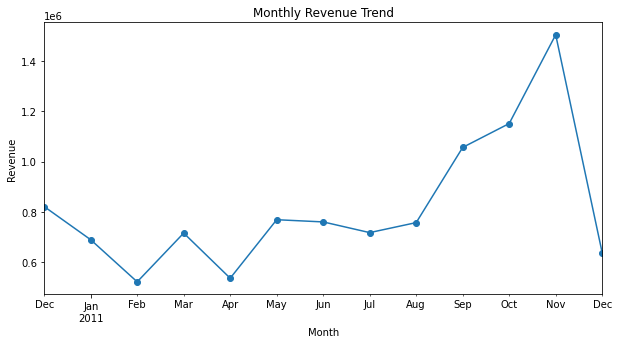

In [19]:
monthly_sales = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig("../images/monthly_revenue.png")

plt.show()

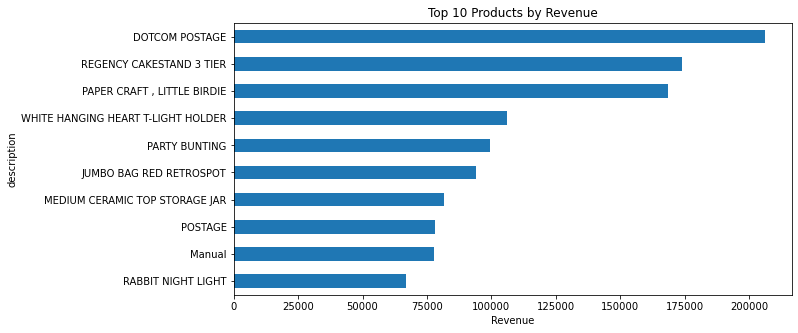

In [20]:
top_products = (
    df.groupby('description')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")

plt.savefig("../images/top_products.png")

plt.show()

In [21]:
## Sales by Country

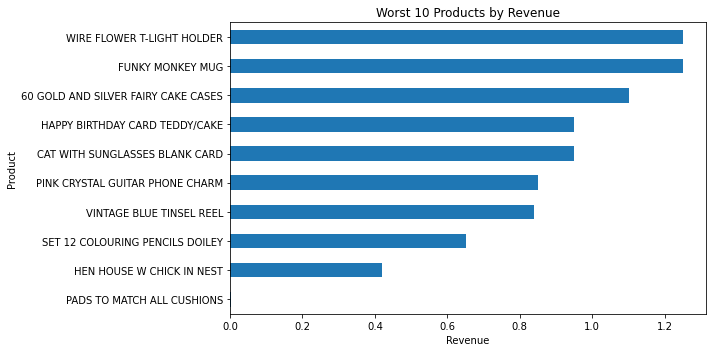

In [22]:
worst_products = (
    df.groupby('description')['revenue']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

plt.figure(figsize=(10, 5))
worst_products.plot(kind='barh')
plt.title("Worst 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../images/worst_products.png")
plt.show()


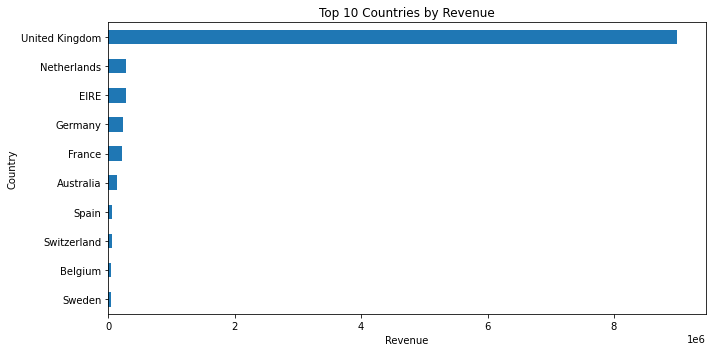

In [23]:
country_sales = (
    df.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
country_sales.sort_values().plot(kind='barh')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../images/country_sales.png")
plt.show()


In [ ]:
## Business Insights

- Revenue is concentrated in a relatively small number of products, meaning a few items drive a large share of total sales.
- Monthly revenue trends show seasonality, with stronger sales in the later months of the year.
- Average order value helps show how much customers spend per transaction and can be used to guide bundling or upsell strategies.
- The top-performing products should be prioritized in promotions, inventory planning, and featured placements.
- Low-performing products may need pricing changes, better visibility, or removal from inventory.
- Revenue is also concentrated in a small number of countries, which may help guide regional marketing decisions.

In [ ]:
## Business Recommendations

- Promote top-performing products more aggressively through featured placements and marketing campaigns.
- Use bundles and cross-sell strategies to increase average order value.
- Review low-performing products for pricing, product-market fit, or possible discontinuation.
- Plan campaigns around high-performing months and create strategies to improve slower months.
- Focus sales and retention efforts on the highest-revenue countries and customer segments.

In [ ]:
## Conclusion

This analysis explored ecommerce transaction data to identify key drivers of sales performance.

Key findings include:
- Revenue is concentrated among a small number of products.
- Sales increase significantly toward the end of the year, suggesting seasonal demand.
- A large portion of revenue comes from a small number of geographic regions.
- Identifying top-performing products can help guide marketing and inventory decisions.

These insights could help the business optimize product offerings, improve marketing strategies, and increase overall revenue.